# Phase 3C — Horizon-Based Baseline Control

In this phase we introduce a horizon-based baseline controller.

Unlike the greedy baseline (Phase 3B), which decides using only the current hour,
this controller looks ahead over a fixed horizon and chooses battery actions
based on the expected system stress over the next hours.

This is still not MPC, but it is closer to how real operators think.

## Why Horizon control?

### Motivation

The greedy controller used only the current hour:
- if net load high → discharge
- if net load low → charge

This caused unrealistic behavior:
- battery emptied too fast
- no anticipation of future stress
- no smoothing across time

Real grid operation always considers the future.

So we build a horizon-based baseline:
- look ahead 24 hours
- estimate system stress
- choose action based on current vs future conditions

### This is still heuristic, but it introduces temporal reasoning before MPC.

In [145]:
import pandas as pd
import matplotlib.pyplot as plt
import os

DATA_DIR = "../data/processed"
print(os.listdir(DATA_DIR))

df = pd.read_csv(
    f"{DATA_DIR}/horizon_baseline_2025.csv",
    parse_dates=["utc_timestamp"]
)

df.head()

['DE_merged_2017.csv', 'DE_merged_2016.csv', 'DE_merged_2015.csv', 'uncertainty_profile_hourly.csv', 'error_stats_global.csv', 'horizon_baseline_2025.csv', 'error_stats_hourly.csv', 'battery_baseline_2025.csv', 'DE_merged_2024.csv', 'DE_merged_2018.csv', 'DE_merged_2019.csv', 'DE_merged_2025.csv', 'DE_merged_2022.csv', 'DE_merged_2023.csv', 'DE_merged_2021.csv', 'error_stats_monthly.csv', 'DE_merged_2020.csv']


,utc_timestamp,hour,horizon_hours,chosen_power_request_mw,load_forecast_mw,solar_forecast_mw,wind_onshore_forecast_mw,wind_offshore_forecast_mw,forecast_net_load_mw,corrected_net_load_mw,reserve_margin_mw,risk_adjusted_net_load_mw,battery_charge_mw,battery_discharge_mw,battery_power_mw,soc_before_mwh,soc_after_mwh,net_load_after_battery_mw
0,2025-01-01 00:00:00+01:00,0,24,12.526287,44518.2425,0.0,38472.2225,3759.6575,2286.3625,1257.336958,3617.732264,4875.069222,0.000000,12.526287,12.526287,50.000000,36.814434,1244.810670
1,2025-01-01 01:00:00+01:00,1,24,0.077117,42269.3500,0.0,38931.1575,3795.0700,-456.8775,-1480.268030,3641.423966,2161.155936,0.000000,0.077117,0.077117,36.814434,36.733259,-1480.345147
2,2025-01-01 02:00:00+01:00,2,24,-6.997664,41095.9975,0.0,39388.8900,3826.1900,-2119.0825,-3191.503610,3675.067769,483.564159,6.997664,0.000000,-6.997664,36.733259,43.381039,-3184.505946
3,2025-01-01 03:00:00+01:00,3,24,-5.629215,40805.1225,0.0,39347.5000,3336.8875,-1879.2650,-2946.249059,3674.782901,728.533843,5.629215,0.000000,-5.629215,43.381039,48.728794,-2940.619844
4,2025-01-01 04:00:00+01:00,4,24,-6.999786,40678.0000,0.0,39681.4475,3213.5925,-2217.0400,-3263.283848,3669.210252,405.926404,6.999786,0.000000,-6.999786,48.728794,55.378590,-3256.284062


In [146]:
df[["soc_before_mwh", "soc_after_mwh"]].head(20)

,soc_before_mwh,soc_after_mwh
0,50.000000,36.814434
1,36.814434,36.733259
2,36.733259,43.381039
3,43.381039,48.728794
4,48.728794,55.378590
5,55.378590,61.746985
6,61.746985,72.111850
7,72.111850,76.189338
8,76.189338,75.097797
9,75.097797,75.044996


We verify that the battery state of charge evolves smoothly.

Unlike the greedy controller,
the horizon baseline does not immediately empty the battery.

In [147]:
df[[
    "chosen_power_request_mw",
    "battery_power_mw",
    "soc_before_mwh",
    "soc_after_mwh"
]].head(20)

,chosen_power_request_mw,battery_power_mw,soc_before_mwh,soc_after_mwh
0,12.526287,12.526287,50.000000,36.814434
1,0.077117,0.077117,36.814434,36.733259
2,-6.997664,-6.997664,36.733259,43.381039
3,-5.629215,-5.629215,43.381039,48.728794
4,-6.999786,-6.999786,48.728794,55.378590
5,-6.703574,-6.703574,55.378590,61.746985
6,-10.910384,-10.910384,61.746985,72.111850
7,-4.292093,-4.292093,72.111850,76.189338
8,1.036964,1.036964,76.189338,75.097797
9,0.050161,0.050161,75.097797,75.044996


We inspect the requested power.

The horizon controller now produces:
- small actions
- both charge and discharge
- no constant saturation

This indicates that the controller is reacting to the horizon,
not only to the current hour.

Important to note that the battery stops changing its state of charge.
This happens because the battery reaches its energy capacity limit.
Once SOC = energy_capacity_mwh, the controller may still request charging,
but the battery model correctly prevents storing more energy.

This is expected behavior and shows that:

- power limits are respected
- energy limits are respected
- the baseline controller does not override physics

In a real system, this means the battery is full and cannot absorb more excess generation.
More advanced control (Phase 4 MPC) will try to avoid reaching the limits too early.

In [148]:
df[[
    "corrected_net_load_mw",
    "net_load_after_battery_mw",
    "reserve_margin_mw"
]].head(20)

,corrected_net_load_mw,net_load_after_battery_mw,reserve_margin_mw
0,1257.336958,1244.810670,3617.732264
1,-1480.268030,-1480.345147,3641.423966
2,-3191.503610,-3184.505946,3675.067769
3,-2946.249059,-2940.619844,3674.782901
4,-3263.283848,-3256.284062,3669.210252
5,-3168.107025,-3161.403450,3724.142174
6,-4314.475556,-4303.565173,4092.006123
7,-2779.071083,-2774.778990,4494.939701
8,-1241.887598,-1242.924562,4851.495290
9,-1001.511748,-1001.561909,5181.305191


We check how the battery modifies net load.

The goal of the baseline is not optimality,
but reducing stress when possible
and absorbing excess when available.

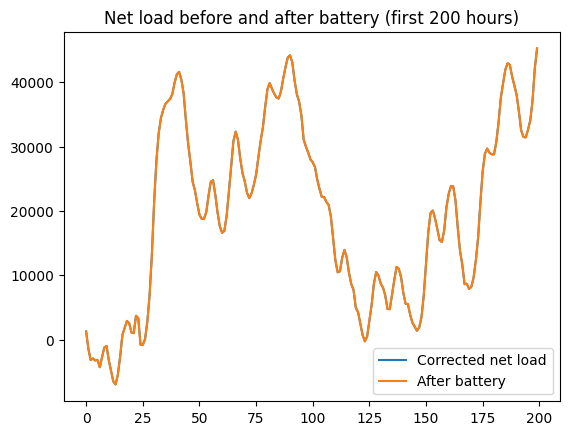

In [149]:
plt.figure()

plt.plot(df["corrected_net_load_mw"][:200], label="Corrected net load")
plt.plot(df["net_load_after_battery_mw"][:200], label="After battery")

plt.legend()
plt.title("Net load before and after battery (first 200 hours)")
plt.show()

The two net load curves appear almost identical because the battery is small
relative to the overall system net load.

Battery power is at most 25 MW, while corrected net load is often several
thousand MW. As a result, the battery effect is physically present but not
visually large on the full system scale.

To observe the battery contribution more clearly, it is better to plot:
- battery_power_mw directly

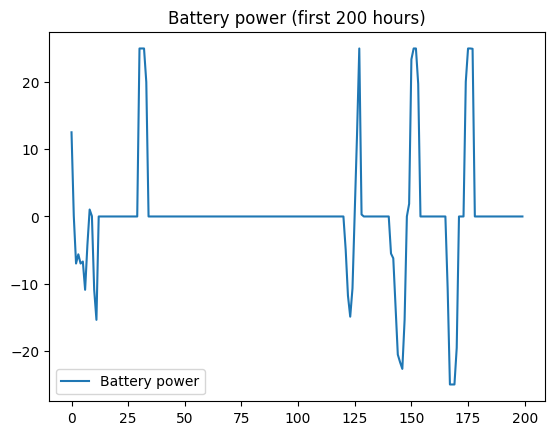

In [150]:
plt.figure()
plt.plot(df["battery_power_mw"][:200], label="Battery power")
plt.legend()
plt.title("Battery power (first 200 hours)")
plt.show()

# Difficulties during Phase 3C

    1. Scaling problems

Early versions used raw MW values,
causing the controller to saturate at maximum power.

    2. Horizon normalization

We introduced normalization using reserve margin
to make signals comparable across hours.

    3. SOC boundary issues

Without soft constraints,
the battery could stay near empty or full.

    4. Trade-off between realism and simplicity

We intentionally keep the controller heuristic,
because Phase 4 will introduce MPC.
"""

# Insights from Phase 3C

- Horizon-based control is more realistic than greedy control.
- Even simple look-ahead improves behavior.
- Battery operation must consider future uncertainty.
- Heuristic control still struggles with optimal timing.
- This motivates the need for formal optimization.

Next step:
Phase 4 — Model Predictive Control (MPC)